# EDA: USK-Coffee (Normal vs Defect)

**Task:** Look at a photo of a green coffee bean and decide: is it a **normal** bean or a **defect** bean?

- **normal** = peaberry + longberry + premium (3 folders merged into 1 class)
- **defect** = defect folder

**Rules in this notebook**
- We check train, val and test **separately**, then **compare** them.
- Numbers used for training (like mean and std) come from **train only**.

## 1. Setup

In [3]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 4.2 MB/s eta 0:00:11
   -- ------------------------------------- 2.9/44.0 MB 9.9 MB/s eta 0:00:05
   ----- ---------------------------------- 6.3/44.0 MB 12.5 MB/s eta 0:00:04
   --------- ------------------------------ 10.0/44.0 MB 13.8 MB/s eta 0:00:03
   ------------ --------------------------- 14.2/44.0 MB 15.3 MB/s eta 0:00:02
   --------------- ------------------------ 16.5/44.0 MB 15.3 MB/s eta 0:00:02
   ---------------- ----------------------- 18.4/44.0 MB 13.6 MB/s eta 0:00:02
   ------------------ --------------------- 20.2/44.0 MB 13.0 MB/s eta 0:00:02
   ------------------- -------------------- 21.2/44.0 MB 12.0 MB/s eta 0:00:02
   -------------------- ------------------- 22.3/44.0 MB 11.4 MB/s eta 0:00:02
   --------------------- ------------------ 23.6/44.0 MB 10.8 MB/s eta 0:00:02
   ---------------------- ----------------- 24.6/44.0 MB 10.3 MB/s

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = Path("data")     # change this if your data is somewhere else
SPLITS = ["train", "val", "test"]

## 2. Make a table of all images

We list every image and give it a label:
- `bean_type` = the original folder name (defect, longberry, peaberry, premium)
- `label` = the new 2-class label (defect or normal)

In [2]:
rows = []
for split in SPLITS:
    for path in sorted((DATA_DIR / split).rglob("*.jpg")):
        bean_type = path.parent.name
        if bean_type == "defect":
            label = "defect"
        else:
            label = "normal"
        rows.append({"path": str(path), "file": path.name, "split": split,
                     "bean_type": bean_type, "label": label})

df = pd.DataFrame(rows)
print("Total images:", len(df))
df.head()

Total images: 8000


,path,file,split,bean_type,label
0,data\train\defect\0.jpg,0.jpg,train,defect,defect
1,data\train\defect\1.jpg,1.jpg,train,defect,defect
2,data\train\defect\10.jpg,10.jpg,train,defect,defect
3,data\train\defect\100.jpg,100.jpg,train,defect,defect
4,data\train\defect\1000.jpg,1000.jpg,train,defect,defect


## 3. Check the files

We open every image to check that it is not broken, and we look at its size and color mode.
A broken file or a gray-scale image can crash training.

In [3]:
sizes = []
modes = []
broken = []

for path in df.path:
    try:
        img = Image.open(path)
        img.verify()                 # error if the file is broken
        img = Image.open(path)       # open again after verify
        sizes.append(img.size)
        modes.append(img.mode)
    except Exception:
        broken.append(path)
        sizes.append(None)
        modes.append(None)

df["size"] = sizes
df["mode"] = modes
print("Broken images:", len(broken))
print(df["size"].value_counts())
print(df["mode"].value_counts())

Broken images: 0
size
(256, 256)    8000
Name: count, dtype: int64
mode
RGB    8000
Name: count, dtype: int64


**What this means**
- No broken images.
- All images are 256×256 and RGB. So we **do not need to resize** or fix channels.

## 4. Class balance

Now there are only 2 classes, so we count them in each split.

label  defect  normal
split                
train    1200    3600
val       400    1200
test      400    1200

Normal : Defect = 3.0 : 1  (train)


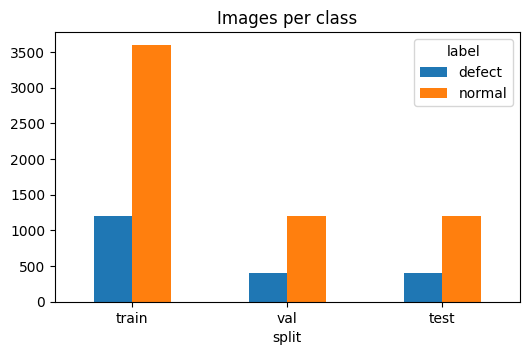


bean_type  defect  longberry  peaberry  premium
split                                          
train        1200       1200      1200     1200
val           400        400       400      400
test          400        400       400      400


In [4]:
counts = df.groupby(["split", "label"]).size().unstack()
counts = counts.loc[SPLITS]
print(counts)
print()
print("Normal : Defect =", counts.loc["train", "normal"] / counts.loc["train", "defect"], ": 1  (train)")

counts.plot.bar(figsize=(6, 3.5), title="Images per class")
plt.xticks(rotation=0)
plt.show()

# what is inside the normal class?
print()
print(df.groupby(["split", "bean_type"]).size().unstack().loc[SPLITS])

**What this means**
- The data is **not balanced anymore**: normal is **3 times** bigger than defect (3600 vs 1200 in train, 1200 vs 400 in val and test).
- The ratio is the same in train, val and test. That is good.
- **Accuracy can fool us.** A model that says "normal" for every image gets **75% accuracy** and finds **0 defects**.
- **What to do:**
  - Use **class weights** (or a weighted sampler) in the loss.
  - Report **recall, precision and F1 for the defect class**, plus a confusion matrix.
- The normal class has 3 bean types (1200 each in train), so it is more varied than the defect class.

## 5. Look at the images

We show 6 random train images from each original folder. The first row is **defect**, the other three rows are **normal**.

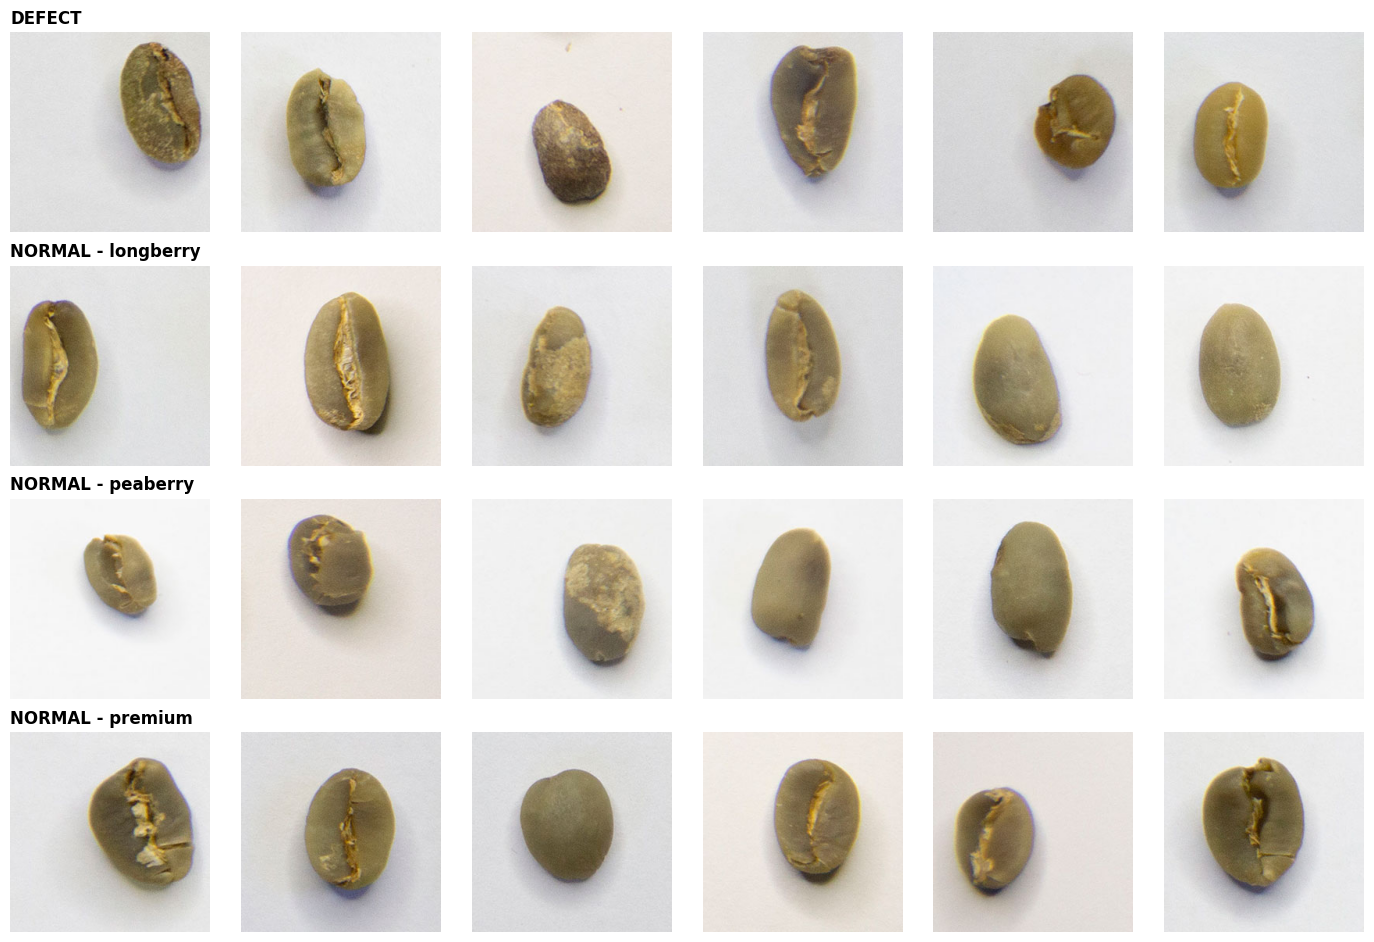

In [5]:
np.random.seed(42)
bean_types = ["defect", "longberry", "peaberry", "premium"]

plt.figure(figsize=(14, 9.5))
n = 1
for bean_type in bean_types:
    train_imgs = df[(df.split == "train") & (df.bean_type == bean_type)]
    chosen = train_imgs.sample(6)
    for i, path in enumerate(chosen.path):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        plt.subplot(4, 6, n)
        plt.imshow(img)
        plt.axis("off")
        if i == 0:
            if bean_type == "defect":
                plt.title("DEFECT", loc="left", fontweight="bold")
            else:
                plt.title("NORMAL - " + bean_type, loc="left", fontweight="bold")
        n += 1
plt.tight_layout()
plt.show()

**What this means**
- Each image has **one bean** on a **light background**. The bean can be anywhere and at any angle.
- **Defect** beans look very different from each other: brown, yellow, rough, broken, or dark and round. It is a mix of many problems class.
- **Normal** beans are mostly smooth and grey-green, but some have a crack in the middle.
- Some defect and normal beans **look alike** (for example, a cracked normal bean next to a rough defect bean). So we expect some mistakes.

## 6. Measure every image

For each image we measure: brightness, contrast, sharpness (low = smoother or blurrier), average R/G/B color, and the color of the background (4 corners).
We also keep a tiny 48×48 gray copy to find duplicates later.

In [6]:
brightness, contrast, sharpness = [], [], []
R, G, B = [], [], []
bgR, bgG, bgB = [], [], []
thumbs = []
md5 = []

for path in df.path:
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    brightness.append(gray.mean())
    contrast.append(gray.std())
    sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var())

    R.append(img[:, :, 0].mean())
    G.append(img[:, :, 1].mean())
    B.append(img[:, :, 2].mean())

    # background = the 4 corners (20x20 pixels each)
    corners = np.concatenate([img[:20, :20].reshape(-1, 3), img[:20, -20:].reshape(-1, 3),
                              img[-20:, :20].reshape(-1, 3), img[-20:, -20:].reshape(-1, 3)])
    bgR.append(corners[:, 0].mean())
    bgG.append(corners[:, 1].mean())
    bgB.append(corners[:, 2].mean())

    thumbs.append(cv2.resize(gray, (48, 48)).astype(np.float32))
    md5.append(hashlib.md5(open(path, "rb").read()).hexdigest())

df["brightness"], df["contrast"], df["sharpness"] = brightness, contrast, sharpness
df["R"], df["G"], df["B"] = R, G, B
df["bgR"], df["bgG"], df["bgB"] = bgR, bgG, bgB
df["bg_brightness"] = (df.bgR + df.bgG + df.bgB) / 3
df["md5"] = md5
thumbs = np.array(thumbs)
df.head()

,path,file,split,bean_type,label,size,mode,brightness,contrast,sharpness,R,G,B,bgR,bgG,bgB,bg_brightness,md5
0,data\train\defect\0.jpg,0.jpg,train,defect,defect,"(256, 256)",RGB,221.784729,49.351985,55.407257,226.692566,220.680542,214.913513,241.789375,236.789375,232.789375,237.122708,fb1b3d1c7468e3a58944de123057a0b6
1,data\train\defect\1.jpg,1.jpg,train,defect,defect,"(256, 256)",RGB,223.453537,41.569375,77.774490,230.580139,222.118759,211.944382,246.564375,241.694375,237.644375,241.967708,e32265051cb0109f7122d75102d8e362
2,data\train\defect\10.jpg,10.jpg,train,defect,defect,"(256, 256)",RGB,229.405838,22.940761,33.521316,232.375580,229.388565,222.573929,238.808750,239.248750,241.678750,239.912083,233569decef3e2419df32fa500b100e4
3,data\train\defect\100.jpg,100.jpg,train,defect,defect,"(256, 256)",RGB,192.485977,40.903298,67.217713,197.175049,192.120224,181.888397,217.942500,218.262500,218.117500,218.107500,b3bb98db837764daaa9f3e4ec0603dda
4,data\train\defect\1000.jpg,1000.jpg,train,defect,defect,"(256, 256)",RGB,212.066635,53.361456,120.594254,222.257004,210.435501,193.982635,247.387500,242.887500,238.637500,242.970833,dc543739213919bbfb30e5af18e27441


## 7. Mean and std for normalization (train only)

In [7]:
total = np.zeros(3)
total_sq = np.zeros(3)
count = 0

for path in df[df.split == "train"].path:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB).astype(np.float64) / 255
    total += img.sum(axis=(0, 1))
    total_sq += (img ** 2).sum(axis=(0, 1))
    count += img.shape[0] * img.shape[1]

train_mean = total / count
train_std = np.sqrt(total_sq / count - train_mean ** 2)
print("Train mean (R, G, B):", train_mean.round(4))
print("Train std  (R, G, B):", train_std.round(4))

Train mean (R, G, B): [0.8313 0.8105 0.7763]
Train std  (R, G, B): [0.1554 0.18   0.2378]


**What this means**
- Use these numbers in `Normalize(mean, std)` for train, val **and** test. Never recompute them on val or test.
- They are different from ImageNet numbers because our images are bright with a light background.

## 8. Normal vs Defect: how different are they?

We compare the simple measurements between the two classes.

        brightness  contrast  sharpness      R      G      B
label                                                       
defect       211.3      42.8       88.6  217.5  210.4  200.1
normal       209.2      43.3       75.1  215.1  208.4  198.4


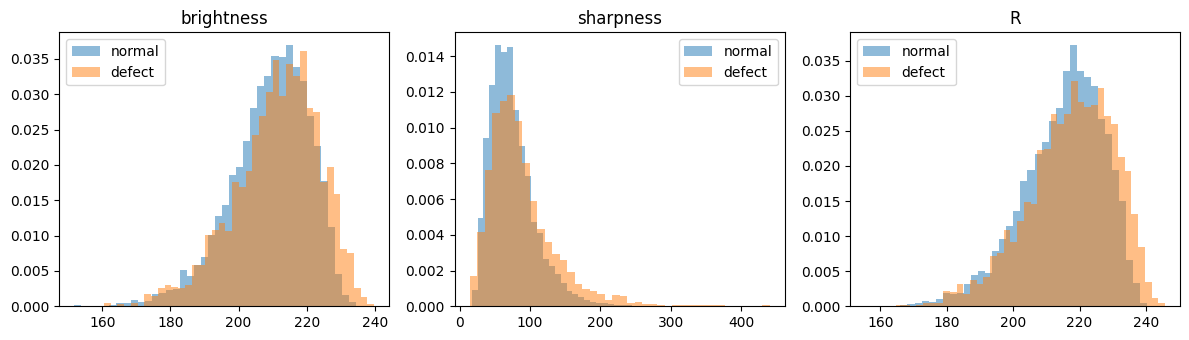

In [8]:
cols = ["brightness", "contrast", "sharpness", "R", "G", "B"]
print(df.groupby("label")[cols].mean().round(1))

plt.figure(figsize=(12, 3.5))
for i, col in enumerate(["brightness", "sharpness", "R"]):
    plt.subplot(1, 3, i + 1)
    plt.hist(df[df.label == "normal"][col], bins=40, alpha=0.5, density=True, label="normal")
    plt.hist(df[df.label == "defect"][col], bins=40, alpha=0.5, density=True, label="defect")
    plt.title(col)
    plt.legend()
plt.tight_layout()
plt.show()

**What this means**
- The two classes are **very close** in brightness, contrast and color. The histograms **overlap a lot**.
- Defect beans are a bit **sharper** (more texture, 89 vs 75), which fits the rough look we saw in Section 5.
- So simple color or brightness will **not** be enough. The model must learn **texture and shape**, so a CNN is a good choice.

## 9. Compare train, val and test

If the splits look different, val and test scores can be unfair or different from each other.

       brightness  bg_brightness  sharpness
split                                      
train       207.2          232.2       79.7
val         213.1          235.8       78.5
test        213.9          235.1       74.8

       brightness               sharpness            
split        test  train    val      test train   val
label                                                
defect      216.4  207.6  217.0      95.1  89.8  78.7
normal      213.0  207.1  211.7      68.0  76.4  78.4


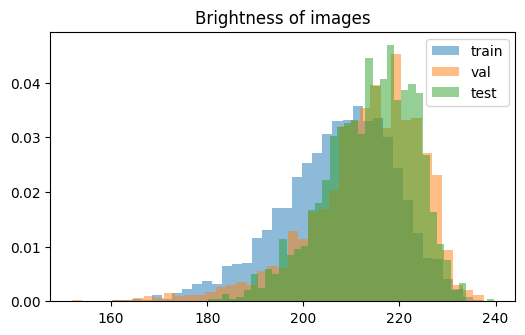

In [9]:
cols = ["brightness", "bg_brightness", "sharpness"]
print(df.groupby("split")[cols].mean().round(1).loc[SPLITS])
print()
print(df.groupby(["label", "split"])[["brightness", "sharpness"]].mean().round(1).unstack())

plt.figure(figsize=(6, 3.5))
for split in SPLITS:
    plt.hist(df[df.split == split].brightness, bins=40, alpha=0.5, density=True, label=split)
plt.title("Brightness of images")
plt.legend()
plt.show()

**What this means**
- **Train images are darker** than val and test (about 207 vs 213 in brightness). The background is darker too.
- This is true for **both** normal and defect, so it is a lighting difference, not a class difference.
- The gap is small to medium, but it is real. **Fix:** use mild brightness/contrast augmentation.
- Sharpness also changes between splits (for example, normal beans in test are smoother than in train). Keep this in mind when you read test results.

## 10. Can the model cheat or is it easy? (simple baseline)

We train a small Random Forest that sees **only numbers** (no shape, no texture). 
- **Background only:** if this works, the model can cheat with the background.
- **Color + brightness of the whole image:** shows how much simple color helps.

We use **balanced accuracy** (random guessing = 50%) and **defect recall** (how many defects we catch), because normal accuracy is fooled by the 3:1 imbalance.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score

train = df[df.split == "train"]

tests = {
    "Background only": ["bgR", "bgG", "bgB"],
    "Whole image color": ["R", "G", "B", "brightness", "contrast"],
}

results = []
for name, features in tests.items():
    model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=0)
    model.fit(train[features], train.label)
    for split in ["val", "test"]:
        part = df[df.split == split]
        pred = model.predict(part[features])
        results.append({"features": name, "split": split,
                        "accuracy": accuracy_score(part.label, pred),
                        "balanced_acc": balanced_accuracy_score(part.label, pred),
                        "defect_recall": recall_score(part.label, pred, pos_label="defect")})

print("Always guess 'normal' -> accuracy 0.75, balanced accuracy 0.50, defect recall 0.00")
pd.DataFrame(results).round(3)

Always guess 'normal' -> accuracy 0.75, balanced accuracy 0.50, defect recall 0.00


,features,split,accuracy,balanced_acc,defect_recall
0,Background only,val,0.703,0.536,0.202
1,Background only,test,0.715,0.521,0.132
2,Whole image color,val,0.771,0.610,0.288
3,Whole image color,test,0.750,0.567,0.200


**What this means**
- With the **background only**, balanced accuracy is about 0.52-0.54, which is almost random. So there is **no background shortcut**. 
- With **whole-image color**, balanced accuracy is only about 0.57-0.61 and the model finds only about 20-29% of defects. So color helps a little but is **far from enough**.
- This is our **weak baseline**. A CNN must beat it by a lot to be useful.

## 11. Duplicates and data leakage

If the same image is in train and test, the test score looks better than it should.
We check exact copies (MD5) and near copies (pixel similarity, also for flipped or rotated images).

Exact duplicates (same MD5): 0
Typical similarity to the closest image: 0.95
Suspicious pairs: 1


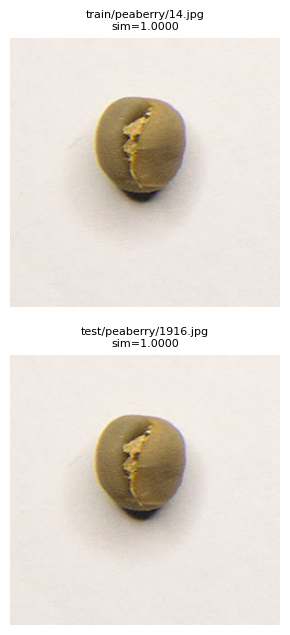

In [11]:
print("Exact duplicates (same MD5):", df.md5.duplicated(keep=False).sum())

# turn each thumbnail into a vector with mean 0 and length 1
def to_vectors(t):
    t = t.reshape(len(t), -1)
    t = t - t.mean(axis=1, keepdims=True)
    return t / (np.linalg.norm(t, axis=1, keepdims=True) + 1e-8)

base = to_vectors(thumbs)
best_score = np.full(len(df), -1.0)
best_match = np.zeros(len(df), dtype=int)

# compare with 8 versions of every image: 4 rotations x (normal or flipped)
for flip in [False, True]:
    for k in range(4):
        other = np.rot90(thumbs, k, axes=(1, 2))
        if flip:
            other = other[:, :, ::-1]
        sim = base @ to_vectors(np.ascontiguousarray(other)).T   # similarity of every pair
        np.fill_diagonal(sim, -1)                                # ignore itself
        score = sim.max(axis=1)
        match = sim.argmax(axis=1)
        better = score > best_score
        best_score[better] = score[better]
        best_match[better] = match[better]

df["match"] = best_match
df["match_score"] = best_score
print("Typical similarity to the closest image: %.2f" % df.match_score.median())

# only very high similarity is suspicious
suspicious = df[df.match_score > 0.99]
pairs = set()
for i, row in suspicious.iterrows():
    pairs.add(tuple(sorted([i, row.match])))
pairs = sorted(pairs)
print("Suspicious pairs:", len(pairs))

plt.figure(figsize=(3 * len(pairs), 6.5))
for k, (a, b) in enumerate(pairs):
    for r, idx in enumerate([a, b]):
        img = cv2.cvtColor(cv2.imread(df.path[idx]), cv2.COLOR_BGR2RGB)
        plt.subplot(2, len(pairs), r * len(pairs) + k + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(df.split[idx] + "/" + df.bean_type[idx] + "/" + df.file[idx] +
                  "\nsim=%.4f" % df.match_score[a], fontsize=8)
plt.tight_layout()
plt.show()

**What this means**
- **No exact copies** (MD5).
- Most images have a similarity of about 0.95 to their closest image. This comes from the **shared light background**, not from real copies. That is why we only check values above 0.99.
- Only **one pair** is above 0.99, and we looked at it by eye: `train/peaberry/14.jpg` and `test/peaberry/1916.jpg` are the **same image** (similarity 1.0). This is a **leak** (both are "normal"). Remove one of them, we suggest from test.
- Tip: if you lower the threshold (for example to 0.98), you will see more pairs. Check them by eye. Most are different beans that just look alike.
- Only 1 leaked image out of 1600 test images, so the effect is tiny, but mention it in your report.

## 12. Summary and decisions

| Check | Result | What we do |
|---|---|---|
| Files, size, channels | No broken files. All 256×256 RGB | No resize or channel fix needed |
| Class balance | Normal : Defect = 3 : 1 in every split | Class weights (or weighted sampler). Report defect recall, precision, F1 and confusion matrix. Do not trust accuracy alone |
| Normalization | Train mean/std in Section 7 | Use for train, val and test |
| Normal vs defect | Very similar in color and brightness. Defect is a bit rougher | Use a CNN, not simple color rules |
| Train vs val/test | Train is a bit darker | Mild brightness/contrast augmentation |
| Background shortcut | None found | - |
| Duplicates | 1 leaked image (train ↔ test) | Remove it from test |
| Simple baseline | Balanced accuracy about 0.57-0.61 | A CNN should be much better |

**Suggested augmentation:** random flips, random rotation (any angle), small shift and zoom, mild brightness/contrast.

**Avoid:** hue shift and strong color jitter, because color is still a useful clue.